In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def load_image(path):
    image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    
    if image is None:
        print("Image not found:", path)
    else:
        return image

In [4]:
def display_images(images, titles):
    plt.figure(figsize=(14, 5))
    
    for i in range(len(images)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(images[i], cmap="gray")
        plt.title(titles[i])
        plt.axis("off")
    
    plt.show()

In [5]:
print("Lab 9: Morphological Operations")
print("In this lab, I applied morphological operations using OpenCV.")
print("The operations include erosion, dilation, opening, closing, and boundary extraction.")

Lab 9: Morphological Operations
In this lab, I applied morphological operations using OpenCV.
The operations include erosion, dilation, opening, closing, and boundary extraction.


1. Erosion
Erosion makes the white objects smaller by removing pixels from their boundaries.


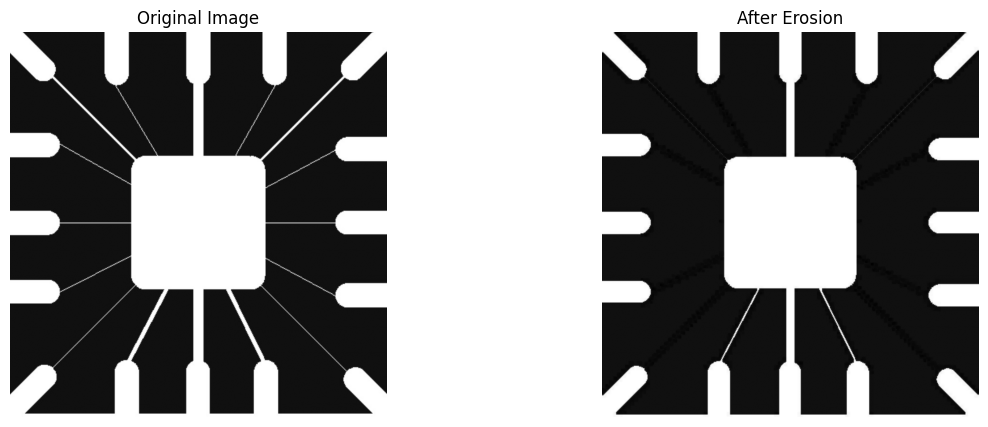

In [6]:
print("1. Erosion")
print("Erosion makes the white objects smaller by removing pixels from their boundaries.")

img_erosion = load_image("Erosion.jpg")

kernel = np.ones((5, 5), np.uint8)

erosion_result = cv2.erode(img_erosion, kernel, iterations=1)

display_images(
    [img_erosion, erosion_result],
    ["Original Image", "After Erosion"]
)

In [7]:
print("Observation:")
print("After applying erosion, the letters became thinner.")
print("Small white parts were reduced because erosion removes pixels from object boundaries.")

Observation:
After applying erosion, the letters became thinner.
Small white parts were reduced because erosion removes pixels from object boundaries.


2. Effect of Erosion Iterations
Here, I applied erosion more than once to see the effect of iterations.


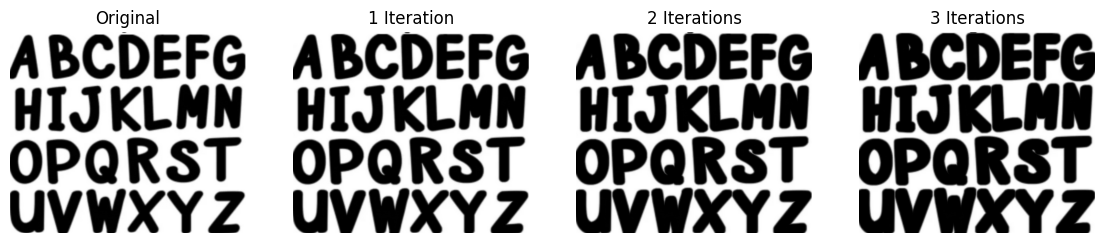

In [8]:
print("2. Effect of Erosion Iterations")
print("Here, I applied erosion more than once to see the effect of iterations.")

img_erosion2 = load_image("Erosion2.jpg")

kernel = np.ones((5, 5), np.uint8)

erosion_1 = cv2.erode(img_erosion2, kernel, iterations=1)
erosion_2 = cv2.erode(img_erosion2, kernel, iterations=2)
erosion_3 = cv2.erode(img_erosion2, kernel, iterations=3)

display_images(
    [img_erosion2, erosion_1, erosion_2, erosion_3],
    ["Original", "1 Iteration", "2 Iterations", "3 Iterations"]
)

In [9]:
print("Observation:")
print("When the number of iterations increased, the white parts became smaller each time.")
print("This shows that erosion becomes stronger when it is repeated.")

Observation:
When the number of iterations increased, the white parts became smaller each time.
This shows that erosion becomes stronger when it is repeated.


3. Dilation
Dilation expands the white regions by adding pixels around object boundaries.


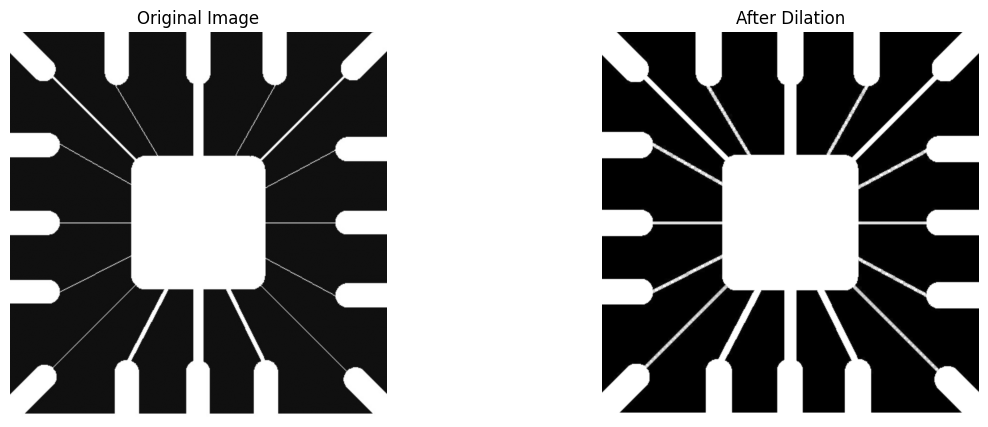

In [10]:
print("3. Dilation")
print("Dilation expands the white regions by adding pixels around object boundaries.")

img_dilation = load_image("Erosion.jpg")

kernel = np.ones((5, 5), np.uint8)

dilation_result = cv2.dilate(img_dilation, kernel, iterations=1)

display_images(
    [img_dilation, dilation_result],
    ["Original Image", "After Dilation"]
)

In [11]:
print("Observation:")
print("After applying dilation, the letters became thicker and larger.")
print("The spaces between some parts became smaller because the white regions expanded.")

Observation:
After applying dilation, the letters became thicker and larger.
The spaces between some parts became smaller because the white regions expanded.


4. Opening
Opening is erosion followed by dilation.
It is mainly used to remove small white noise from an image.


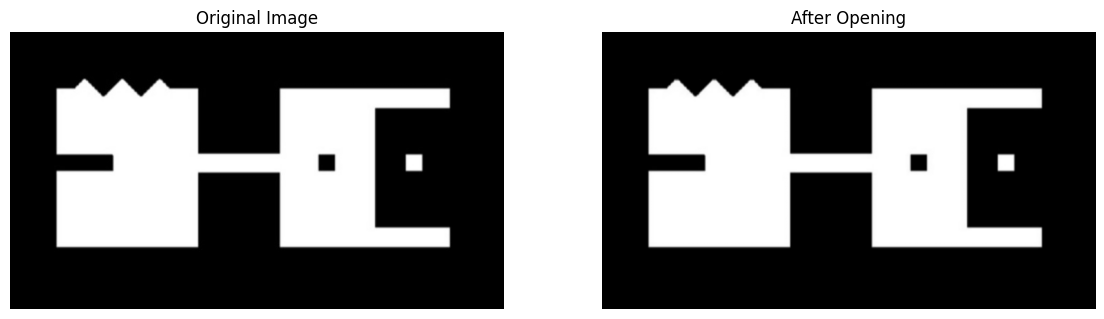

In [12]:
print("4. Opening")
print("Opening is erosion followed by dilation.")
print("It is mainly used to remove small white noise from an image.")

img_opening = load_image("Opening2.jpg")

kernel = np.ones((5, 5), np.uint8)

opening_result = cv2.morphologyEx(img_opening, cv2.MORPH_OPEN, kernel)

display_images(
    [img_opening, opening_result],
    ["Original Image", "After Opening"]
)

In [13]:
print("Observation:")
print("The opening operation removed many small white dots from the image.")
print("The larger objects stayed visible, but the small noise was reduced.")

Observation:
The opening operation removed many small white dots from the image.
The larger objects stayed visible, but the small noise was reduced.


5. Closing
Closing is dilation followed by erosion.
It is mainly used to fill small black holes or gaps inside white objects.


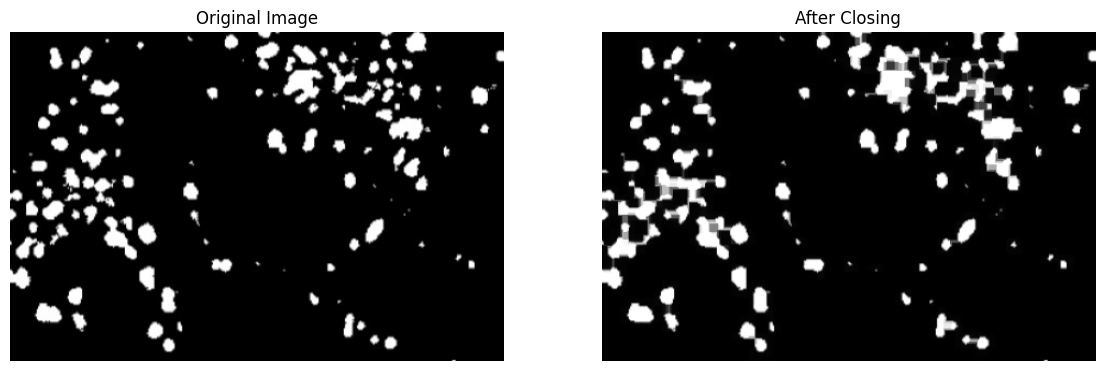

In [14]:
print("5. Closing")
print("Closing is dilation followed by erosion.")
print("It is mainly used to fill small black holes or gaps inside white objects.")

img_closing = load_image("Open_Closing.jpg")

kernel = np.ones((7, 7), np.uint8)

closing_result = cv2.morphologyEx(img_closing, cv2.MORPH_CLOSE, kernel)

display_images(
    [img_closing, closing_result],
    ["Original Image", "After Closing"]
)

In [15]:
print("Observation:")
print("After applying closing, some small black gaps inside the white objects became smaller.")
print("This operation helped make the white objects more connected.")

Observation:
After applying closing, some small black gaps inside the white objects became smaller.
This operation helped make the white objects more connected.


6. Opening and Closing Comparison
Opening removes small white noise, while closing fills small black holes.


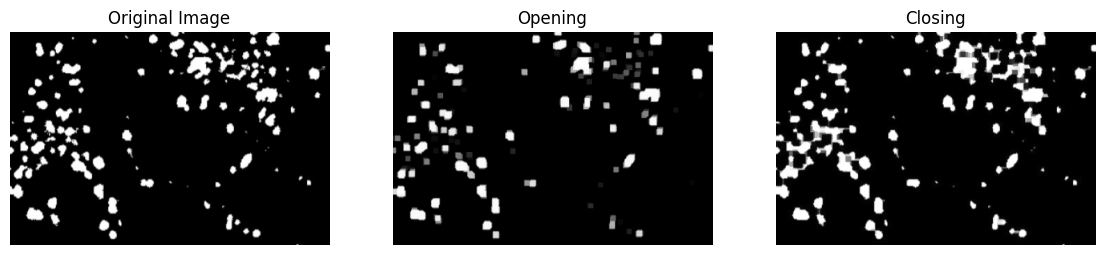

In [16]:
print("6. Opening and Closing Comparison")
print("Opening removes small white noise, while closing fills small black holes.")

img_compare = load_image("Open_Closing.jpg")

kernel = np.ones((7, 7), np.uint8)

opening_compare = cv2.morphologyEx(img_compare, cv2.MORPH_OPEN, kernel)
closing_compare = cv2.morphologyEx(img_compare, cv2.MORPH_CLOSE, kernel)

display_images(
    [img_compare, opening_compare, closing_compare],
    ["Original Image", "Opening", "Closing"]
)

In [17]:
print("Observation:")
print("Opening and closing gave different results because they are used for different problems.")
print("Opening removed small white parts, while closing filled small dark spaces inside the object.")

Observation:
Opening and closing gave different results because they are used for different problems.
Opening removed small white parts, while closing filled small dark spaces inside the object.


7. Boundary Extraction
Boundary extraction is used to find the outline of an object.
Boundary = Original Image - Eroded Image


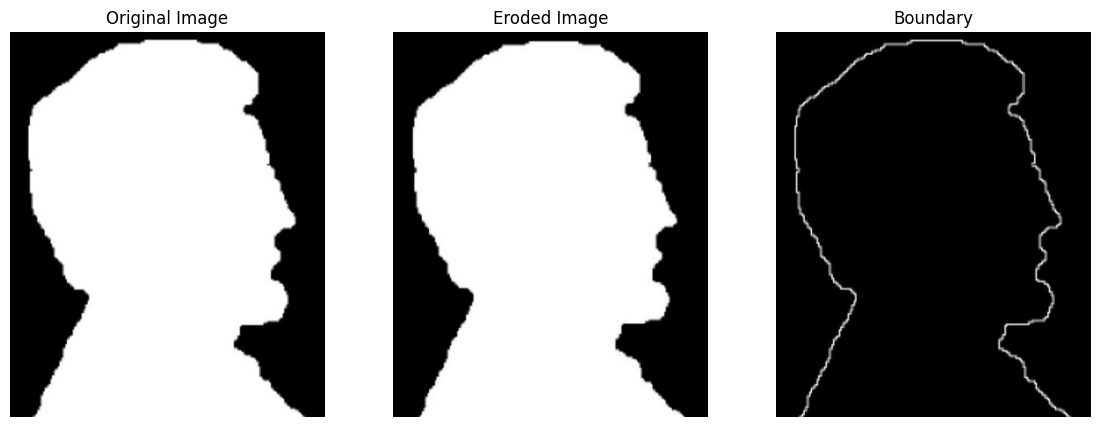

In [18]:
print("7. Boundary Extraction")
print("Boundary extraction is used to find the outline of an object.")
print("Boundary = Original Image - Eroded Image")

img_boundary = load_image("BoundaryExtraction.jpg")

kernel = np.ones((5, 5), np.uint8)

eroded_boundary = cv2.erode(img_boundary, kernel, iterations=1)

boundary_result = img_boundary - eroded_boundary

display_images(
    [img_boundary, eroded_boundary, boundary_result],
    ["Original Image", "Eroded Image", "Boundary"]
)

In [19]:
print("Observation:")
print("The result shows only the outer border of the object.")
print("This happened because the eroded image was smaller than the original image.")
print("Subtracting them kept only the boundary pixels.")

Observation:
The result shows only the outer border of the object.
This happened because the eroded image was smaller than the original image.
Subtracting them kept only the boundary pixels.


8. Morphological Gradient
Morphological gradient is another way to show object edges.
It is calculated from the difference between dilation and erosion.


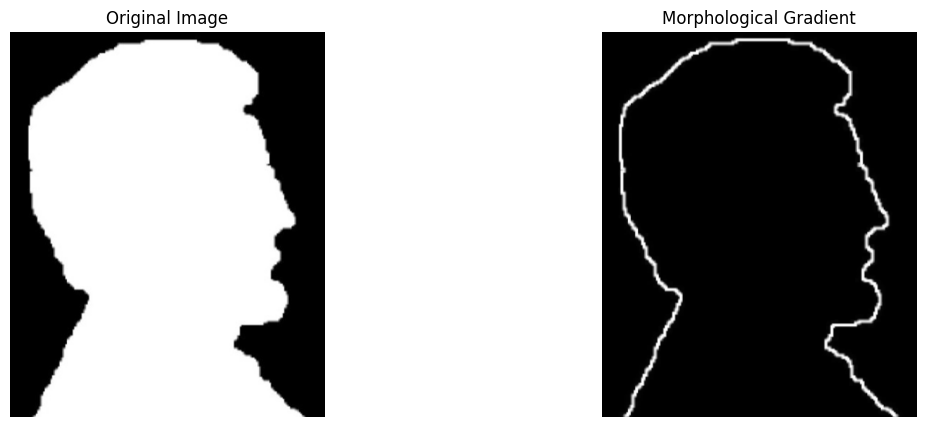

In [20]:
print("8. Morphological Gradient")
print("Morphological gradient is another way to show object edges.")
print("It is calculated from the difference between dilation and erosion.")

img_gradient = load_image("BoundaryExtraction.jpg")

kernel = np.ones((5, 5), np.uint8)

gradient_result = cv2.morphologyEx(img_gradient, cv2.MORPH_GRADIENT, kernel)

display_images(
    [img_gradient, gradient_result],
    ["Original Image", "Morphological Gradient"]
)

In [21]:
print("Observation:")
print("The morphological gradient showed the edges of the object clearly.")
print("It is useful for detecting the shape outline in binary images.")

Observation:
The morphological gradient showed the edges of the object clearly.
It is useful for detecting the shape outline in binary images.


In [22]:
print("Final Conclusion")
print("In this lab, I learned how morphological operations can change the shape of objects in binary images.")
print("Erosion made the white objects smaller.")
print("Dilation made the white objects larger.")
print("Opening removed small white noise.")
print("Closing filled small black holes and gaps.")
print("Boundary extraction and morphological gradient were useful for detecting object edges.")

Final Conclusion
In this lab, I learned how morphological operations can change the shape of objects in binary images.
Erosion made the white objects smaller.
Dilation made the white objects larger.
Opening removed small white noise.
Closing filled small black holes and gaps.
Boundary extraction and morphological gradient were useful for detecting object edges.
